# Normal Distribution for Every Feature

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

In [2]:
raw_train_sample = pd.read_csv('../Modeling/train_sample_1.csv')

raw_train_sample.shape

(1280305, 48)

In [4]:
# 1. Filter only the numeric columns from your list that exist in the dataframe
# This effectively removes 'datetime', 'station_name', 'date', etc.
numeric_cols = raw_train_sample.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols

['station_id',
 'hour',
 'day_of_week',
 'month',
 'year',
 'trips_started',
 'trips_ended',
 'net_flow',
 'temp_c',
 'dew_point_c',
 'rel_humidity_pct',
 'precip_mm',
 'wind_speed_kmh',
 'visibility_km',
 'pressure_kpa',
 'latitude',
 'longitude',
 'capacity',
 'bus',
 'subway',
 'streetcar',
 'train',
 'public_transport_total',
 'tourism',
 'office',
 'park',
 'healthcare',
 'education',
 'restaurants_bars',
 'commercial',
 'cluster_east_end',
 'cluster_scarborough',
 'cluster_uptown',
 'cluster_west_end',
 'dist_to_union_km',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'month_sin',
 'month_cos',
 'day_of_year']

In [ ]:
# 2. Setup the Grid
num_plots = len(numeric_cols)
cols_grid = 4  # How many charts per row
rows_grid = math.ceil(num_plots / cols_grid)

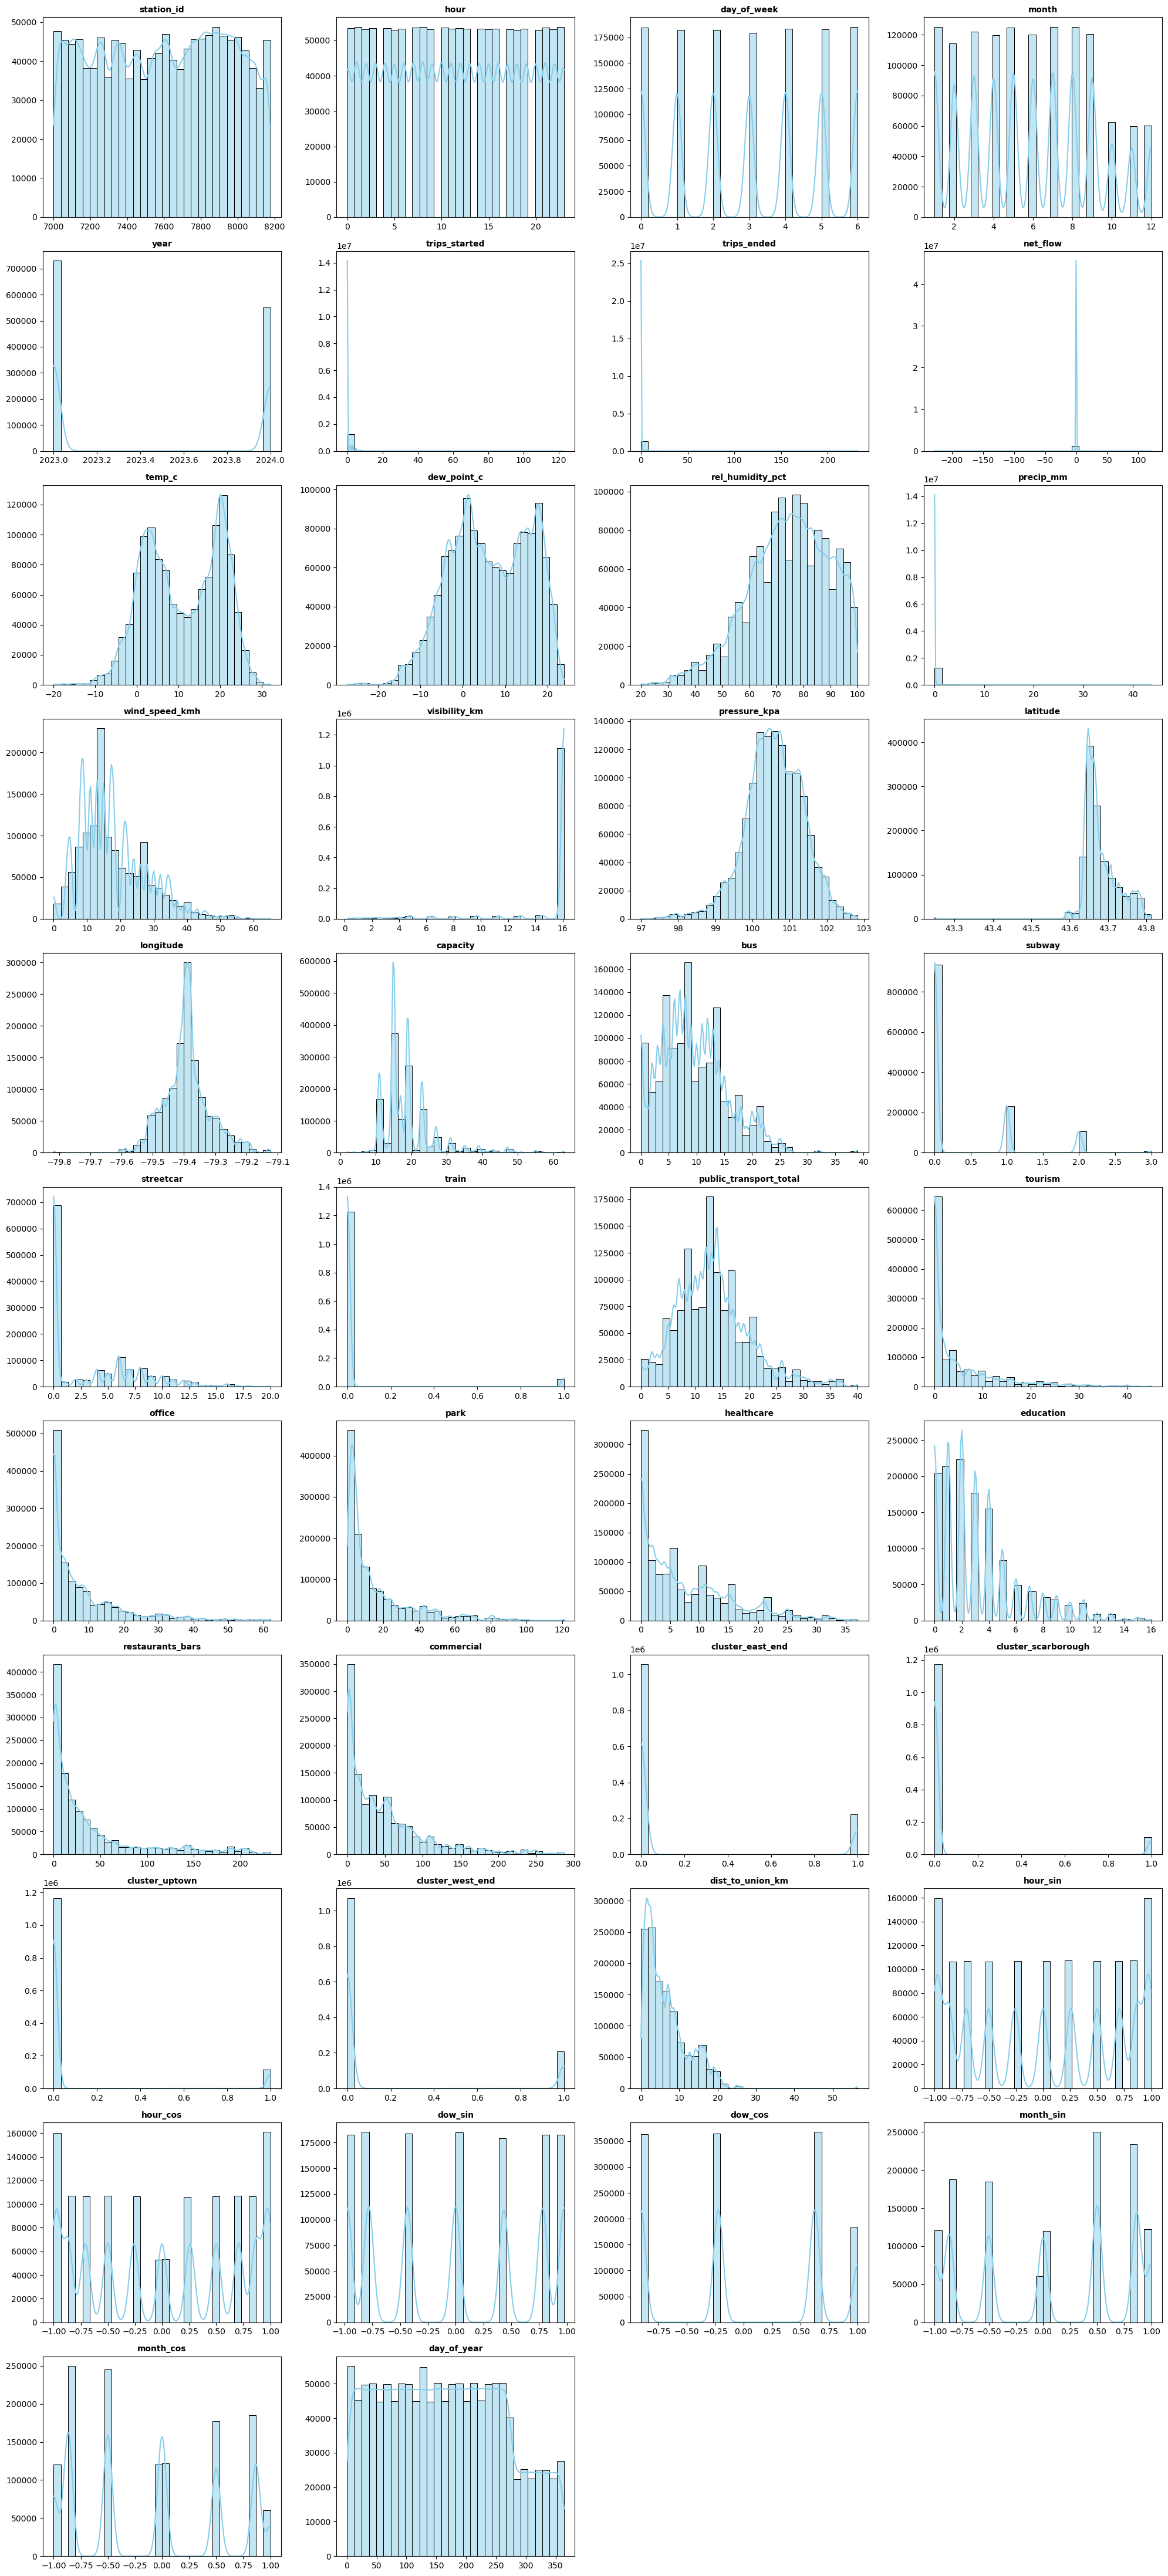

In [6]:
# 3. Create the Plot
# We adjust the figure size dynamically based on how many rows we need
fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(20, rows_grid * 4))
axes = axes.flatten() # Flatten the 2D grid to 1D for easy looping

for i, col in enumerate(numeric_cols):
    # Plot Histogram with a Density Line (KDE)
    sns.histplot(raw_train_sample[col], kde=True, ax=axes[i], color='skyblue', bins=30)
    
    # Formatting
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')

# 4. Remove empty subplots (if your total plots don't fill the last row perfectly)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()